In [6]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


    Peak #  D35Cl Wavenumber  D35Cl Absorbance  D37Cl Wavenumber  \
0        1       2201.952972          0.048905       2198.578305   
1        2       2193.997960          0.059135       2190.743822   
2        3       2185.922607          0.096639       2182.668470   
3        4       2177.485288          0.104743       2174.230988   
4        5       2168.927823          0.146059       2165.673601   
5        6       2160.008759          0.168066       2156.754432   
6        7       2150.848642          0.186086       2147.714677   
7        8       2141.447104          0.189969       2138.313412   
8        9       2131.804780          0.183162       2129.996917   
9       10       2121.921398          0.146059       2118.908129   
10      11       2111.797018          0.108853       2108.783587   
11      12       2101.552025          0.104356       2098.538594   
12      13       2080.097697          0.063939       2077.204958   
13      14       2069.129611          0.118387  

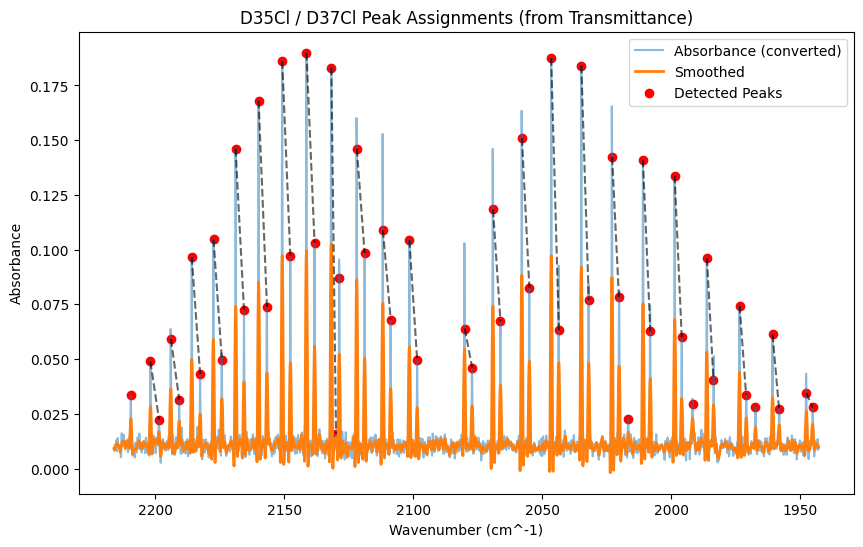

In [7]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, savgol_filter
import matplotlib.pyplot as plt

# === 1. LOAD DATA ===
df = pd.read_csv("dcl_ir-trans.csv")

# Update column names if needed
x = df['wavenumber'].values
T = df['transmittance'].values  # <-- your column

# === 2. CONVERT TRANSMITTANCE → ABSORBANCE ===

A = -np.log10(T)

# === 3. SMOOTH DATA ===
A_smooth = savgol_filter(A, window_length=11, polyorder=3)

# === 4. FIND PEAKS (now normal maxima) ===
peaks, properties = find_peaks(A_smooth, prominence=0.01)

# === 5. SORT PEAKS BY WAVENUMBER ===
sorted_indices = sorted(peaks, key=lambda i: x[i], reverse=True)

# === 6. PAIR PEAKS ===
pairs = []
used = set()
tolerance = 5  # cm^-1

for i in range(len(sorted_indices)):
    if i in used:
        continue
        
    for j in range(i + 1, len(sorted_indices)):
        if j in used:
            continue
        
        idx1 = sorted_indices[i]
        idx2 = sorted_indices[j]
        
        if abs(x[idx1] - x[idx2]) < tolerance:
            if x[idx1] > x[idx2]:
                d35 = idx1
                d37 = idx2
            else:
                d35 = idx2
                d37 = idx1
            
            pairs.append((d35, d37))
            used.add(i)
            used.add(j)
            break

# === 7. BUILD TABLE ===
rows = []

for n, (d35, d37) in enumerate(pairs, start=1):
    rows.append({
        "Peak #": n,
        "D35Cl Wavenumber": x[d35],
        "D35Cl Absorbance": A[d35],
        "D37Cl Wavenumber": x[d37],
        "D37Cl Absorbance": A[d37],
        "Delta nu (cm^-1)": x[d35] - x[d37]
    })

table = pd.DataFrame(rows)
table = table.sort_values(by="D35Cl Wavenumber", ascending=False)

print(table)

# === 8. PLOT ===
plt.figure(figsize=(10,6))
plt.plot(x, A, label='Absorbance (converted)', alpha=0.5)
plt.plot(x, A_smooth, label='Smoothed', linewidth=2)

plt.scatter(x[peaks], A[peaks], color='red', label='Detected Peaks')

for d35, d37 in pairs:
    plt.plot([x[d35], x[d37]], [A[d35], A[d37]], 'k--', alpha=0.6)

plt.xlabel("Wavenumber (cm^-1)")
plt.ylabel("Absorbance")
plt.title("D35Cl / D37Cl Peak Assignments (from Transmittance)")
plt.legend()
plt.gca().invert_xaxis()

plt.show()

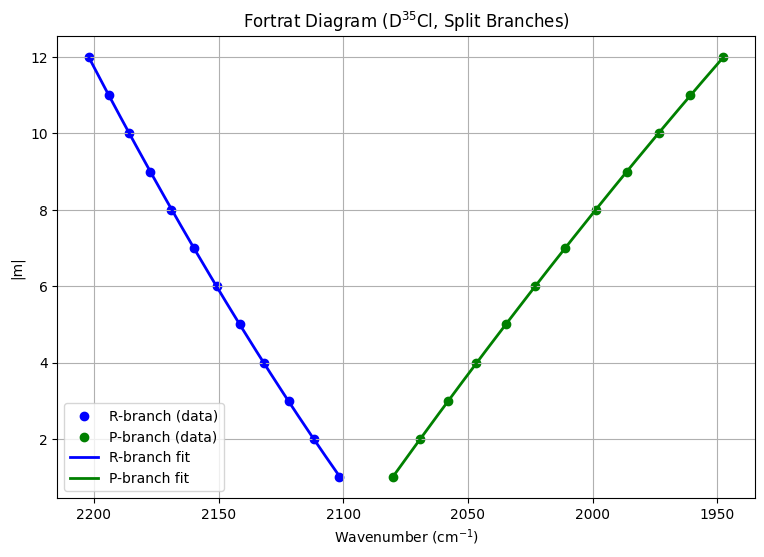

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === LOAD DATA ===
df = pd.read_csv("peak_assignments.csv")
wavenumbers = df["D35Cl Wavenumber"].values

# === SORT WAVENUMBERS ===
wavenumbers = np.sort(wavenumbers)

# === SPLIT INTO P AND R BRANCHES ===
# Use midpoint as a simple separator (you can refine if needed)
center = np.mean(wavenumbers)

R = wavenumbers[wavenumbers > center]
P = wavenumbers[wavenumbers < center]

# Sort each branch properly
R = np.sort(R)            # increasing
P = np.sort(P)[::-1]      # decreasing (so it lines up nicely)

# === ASSIGN |m| VALUES ===
m_R = np.arange(1, len(R) + 1)
m_P = np.arange(1, len(P) + 1)

# === FIT CURVES (quadratic works well for Fortrat diagrams) ===
coeff_R = np.polyfit(R, m_R, 2)
coeff_P = np.polyfit(P, m_P, 2)

x_R_fit = np.linspace(min(R), max(R), 200)
y_R_fit = np.polyval(coeff_R, x_R_fit)

x_P_fit = np.linspace(min(P), max(P), 200)
y_P_fit = np.polyval(coeff_P, x_P_fit)

# === PLOT ===
plt.figure(figsize=(9,6))

# نقاط (data points)
plt.scatter(R, m_R, color='blue', label='R-branch (data)')
plt.scatter(P, m_P, color='green', label='P-branch (data)')

# منحنيات (smooth fits)
plt.plot(x_R_fit, y_R_fit, color='blue', linewidth=2, linestyle='-',
         label='R-branch fit')
plt.plot(x_P_fit, y_P_fit, color='green', linewidth=2, linestyle='-',
         label='P-branch fit')

plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("|m|")
plt.title("Fortrat Diagram (D$^{35}$Cl, Split Branches)")
plt.legend()
plt.grid(True)

# IR convention (high → low left to right)
plt.gca().invert_xaxis()

plt.show()